# Tweet Data Cleaning for Sentiment Analysis

**Input:** `Tweets_Trainset_for_Explainable_AI.txt`
Tab-separated, 3 columns, no header: `id`, `entities` (NER tags), `raw_text`

**Note:** this file has NER labels (PER/ORG/LOC/MISC), not sentiment labels.
This notebook cleans the tweet text and produces a `clean_text` column ready
for a sentiment model (VADER, a transformer, or your own classifier).
The cleaning choices below are deliberately tuned for sentiment analysis,
not generic NLP preprocessing - see the markdown notes before each step.

## 1. Imports

In [1]:
import re
import html
import pandas as pd
import numpy as np

## 2. Load and parse the raw file

The file is tab-separated but **not** a clean TSV - tweet text itself can
contain tabs/odd characters, so we split on `\t` and keep only well-formed
3-column lines, skipping anything malformed rather than silently
misaligning columns.

In [2]:
INPUT_PATH = "Tweets Trainset for Explainable AI.txt"  # update path if needed

df = pd.read_csv(INPUT_PATH, sep='\t', names=['id', 'entities', 'raw_text'])
df

,id,entities,raw_text
0,1,LOC/Thai Buddhist temple;,"2,000 fetuses found hidden at Thai Buddhist te..."
1,2,LOC/canada;,"870, 000 people in canada depend on #FakeHasht..."
2,3,PER/louis;,"7961212234, phone this girl! she is like louis..."
3,4,ORG/WikiLeaks;LOC/Southern Ocean;,@FakeUsername : WikiLeaks Set To Reveal US-UFO...
4,5,ORG/queen;,"@FakeUsername queen, bohemian rhapsody please"
...,...,...,...
2810,2811,LOC/Britain;PER/John Lennon;,RT @FakeUsername : On this date in 1969 : As a...
2811,2812,NaN,RT @FakeUsername : A good friend understands y...
2812,2813,PER/Michael Jordan;,RT @FakeUsername : A pop-up experience celebra...
2813,2814,PER/Hugh Hefner;,RT @FakeUsername : Hugh Hefner is 84 and engag...


## 3. Cleaning function


| Keep | Why |
|---|---|
| Capitalization (`AMAZING`) | signals intensity/emphasis |
| Punctuation (`!!!`, `?!`) | signals intensity/emphasis |
| Emoticons (`:)`, `:(`) | direct sentiment cues |
| Negations (`not`, `n't`) | flips polarity, must stay in context |
| Stopwords | needed for negation scope, contractions |

| Remove | Why |
|---|---|
| URLs | no sentiment content, pure noise |
| @mentions | no sentiment content, pure noise |
| Anonymization placeholders (`@FakeUsername`, `http://FakeURL`, `#FakeHashtag`) | dataset-specific artifacts, dropped because no recoverable signal |
| HTML entities (`&amp;`) | encoding artifact, not real content |
| Extra whitespace / dangling punctuation from removals | cleanup artifact |

In [3]:
PLACEHOLDER_PATTERNS = [
    r"http://FakeURL\)?",
    r"@FakeUsername",
    r"#FakeHashtag",
]
URL_PATTERN = r"https?://\S+"
MENTION_PATTERN = r"@\w+"


def clean_text(text: str) -> str:
    """Clean a single tweet for sentiment analysis.

    Removes noise (URLs, mentions, anonymization artifacts, encoding
    issues) while preserving case, punctuation, and emoticons that
    sentiment models rely on.
    """
    if not isinstance(text, str):
        return ""

    t = html.unescape(text)

    # remove dataset-specific anonymization placeholders first
    for pat in PLACEHOLDER_PATTERNS:
        t = re.sub(pat, " ", t)

    # remove any real URLs / mentions that weren't anonymized
    t = re.sub(URL_PATTERN, " ", t)
    t = re.sub(MENTION_PATTERN, " ", t)

    # drop a colon left dangling where a mention used to be,
    # e.g. "@user : great game" -> "great game"
    t = re.sub(r"^\s*:\s*", "", t)
    t = re.sub(r"\s+:\s+", " ", t)

    # normalize scraped smart-quote artifacts (``...'' style -> "...")
    t = t.replace("``", '"').replace("''", '"')
    t = t.replace("`", "'")

    # collapse whitespace
    t = re.sub(r"\s+", " ", t).strip()

    # trim stray leading/trailing punctuation left after removals
    t = re.sub(r"^[\-:;,.\)\(]+\s*", "", t)
    t = re.sub(r"\s*[\-:;,]+$", "", t)

    return t.strip()

## 4. Apply cleaning

In [4]:
df["clean_text"] = df["raw_text"].apply(clean_text)
df[["raw_text", "clean_text"]].head(10)

,raw_text,clean_text
0,"2,000 fetuses found hidden at Thai Buddhist te...","2,000 fetuses found hidden at Thai Buddhist te..."
1,"870, 000 people in canada depend on #FakeHasht...","870, 000 people in canada depend on -25% incre..."
2,"7961212234, phone this girl! she is like louis...","7961212234, phone this girl! she is like louis..."
3,@FakeUsername : WikiLeaks Set To Reveal US-UFO...,WikiLeaks Set To Reveal US-UFO War In Southern...
4,"@FakeUsername queen, bohemian rhapsody please","queen, bohemian rhapsody please"
5,cheryl cole is starting to lose that connectio...,cheryl cole is starting to lose that connectio...
6,"Lester, '' Mason & Begg Limited : '' '' `Forbi...","Lester, "" Mason & Begg Limited "" "" 'Forbidden ..."
7,"To be successful, you have to have your heart ...","To be successful, you have to have your heart ..."
8,"Sanchez looks like Eli Wallach in The Good, Th...","Sanchez looks like Eli Wallach in The Good, Th..."
9,"@FakeUsername the history of the mayor, the ci...","the history of the mayor, the city ."


## 5. Drop empty and duplicate rows

Some tweets are nothing but a removed mention/URL/hashtag, leaving an empty
string after cleaning - these carry no signal and are dropped. Exact
duplicate tweets (common in scraped corpora, e.g. retweets) are also
dropped to avoid double-counting in any downstream analysis.

In [5]:
before = len(df)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
dropped_empty = before - len(df)

before = len(df)
df = df.drop_duplicates(subset="clean_text").reset_index(drop=True)
dropped_dupes = before - len(df)

print(f"Dropped {dropped_empty} empty rows after cleaning")
print(f"Dropped {dropped_dupes} duplicate rows")
print(f"Final row count: {len(df)}")

Dropped 13 empty rows after cleaning
Dropped 72 duplicate rows
Final row count: 2730


## 6. Inspect cleaned dataset

In [6]:
df[["id", "entities", "raw_text", "clean_text"]].sample(10, random_state=1)

,id,entities,raw_text,clean_text
1357,1409,PER/Brandon Jacobs;,Brandon Jacobs for the great run #FakeHashtag,Brandon Jacobs for the great run
2310,2377,MISC/super bowl;,Never doubt the #FakeHashtag ... super bowl he...,Never doubt the ... super bowl here we come!
2666,2737,PER/Robert Daley;,RT @FakeUsername : 15-year-old boy gets life s...,RT 15-year-old boy gets life sentence for murd...
1875,1937,PER/don;PER/edward cullen;,i love don the vampire king's voice . very dee...,i love don the vampire king's voice . very dee...
1185,1230,NaN,75B just left types fast . Claims to be YHOO-D...,75B just left types fast . Claims to be YHOO-D...
1073,1114,PER/Donnell;,#FakeHashtag #FakeHashtag `Donnell A Rosie Ch...,'Donnell A Rosie Christmas album
403,413,PER/Federer;PER/Nadal;MISC/ATP World Tour;PER/...,@FakeUsername Federer outlasts Nadal in finals...,Federer outlasts Nadal in finals of ATP World ...
958,992,LOC/spain;,@FakeUsername im with my friends im going to y...,im with my friends im going to your concert in...
598,616,NaN,@FakeUsername : South Korean president : #Fake...,South Korean president will respond to future ...
1779,1838,PER/Carlos Xuma;,``http://FakeURL Beware The Alfie by Carlos Xu...,""" Beware The Alfie by Carlos Xuma """


## 7. Save cleaned data

Saved with the original `entities` (NER tags) column retained, in case you
need it for context or a multi-task setup later.

In [7]:
OUTPUT_PATH = "tweets_cleaned.csv"
df_train = df[["id", "entities", "clean_text"]].to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df)} cleaned rows to {OUTPUT_PATH}")

Saved 2730 cleaned rows to tweets_cleaned.csv


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# 1. Load data
df = pd.read_csv("tweets_cleaned.csv")
df['clean_text'] = df['clean_text'].fillna("")

# 2. Helper function to flag entity presence
def has_entity(entity_str, label):
    if pd.isna(entity_str):
        return 0
    return 1 if label in str(entity_str).upper() else 0

# 3. Create our binary target columns
target_labels = ['LOC', 'PER', 'ORG', 'MISC']
for label in target_labels:
    df[f'has_{label}'] = df['entities'].apply(lambda x: has_entity(x, label))

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], 
    df[[f'has_{l}' for l in target_labels]], 
    test_size=0.2, 
    random_state=42
)

Tweet: "Machine thinks The Dark Knight Rises Will be his Last Batman Movie​"
Words recognized by model vocabulary: ['dark', 'machine', 'movie', 'thinks']
------------------------------------------------------------
Tweet: "Machine thinks The Dark Knight Rises Will be his Last Batman Movie​"
-> Predicted Categories: ['PER']

--- Driving Word Attributions (SHAP) ---
For Target [PER]:
  • Token 'thinks' value drove prediction up by +0.2345
  • Token 'dark' value drove prediction up by +0.1427


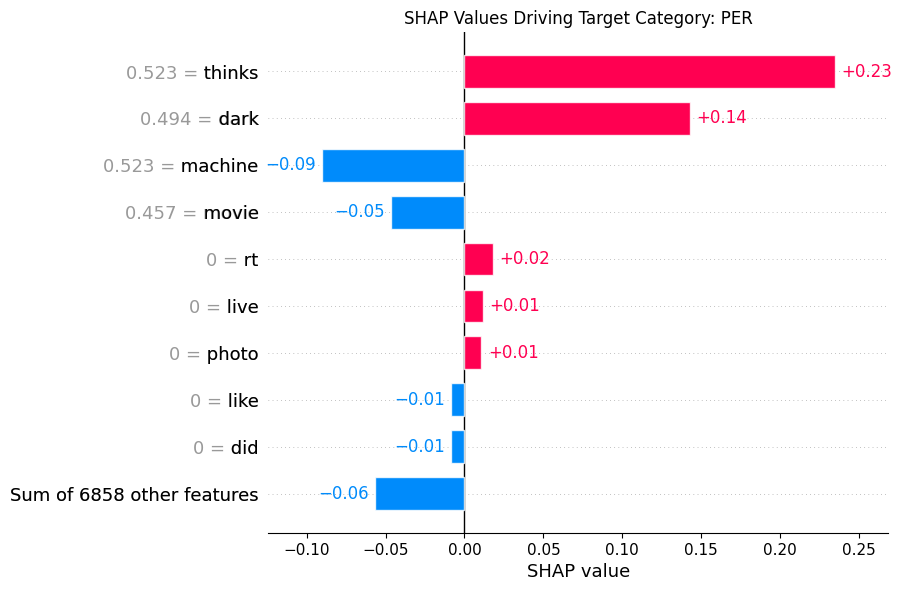

Tweet: "Jennifer Biel is soooooo bangin. Wtf?"
Words recognized by model vocabulary: ['jennifer', 'wtf']
------------------------------------------------------------
Tweet: "Jennifer Biel is soooooo bangin. Wtf?"
-> Predicted Categories: ['PER']

--- Driving Word Attributions (SHAP) ---
For Target [PER]:
  • Token 'jennifer' value drove prediction up by +0.1203
  • Token 'wtf' value drove prediction up by +0.0000


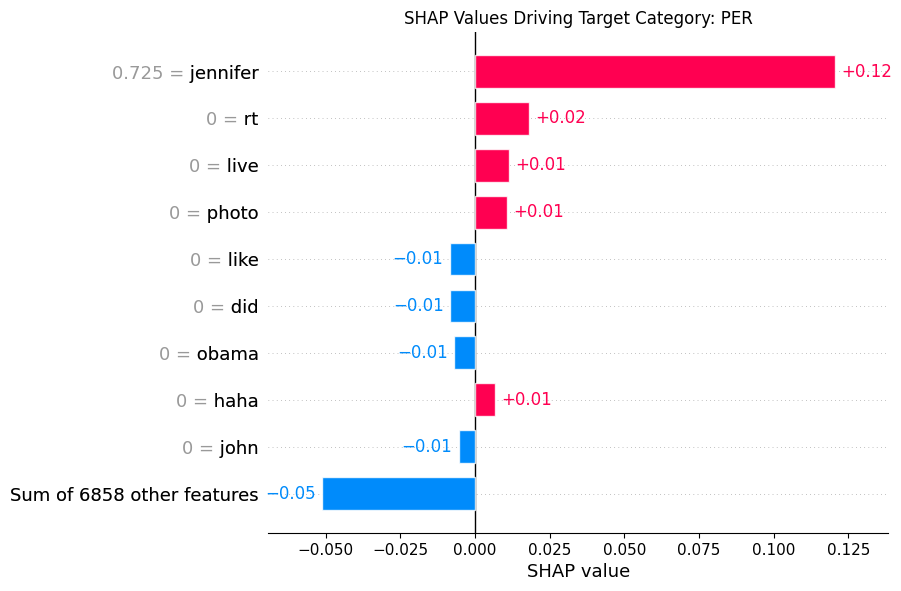

In [ ]:
# We let the vectorizer dynamically size itself, then pull that size to build the SHAP matrices.
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train).toarray()
feature_names = vectorizer.get_feature_names_out()

# Get the EXACT runtime feature count (e.g., 2314, 4100, etc.)
DYN_FEATURES_COUNT = X_train_vec.shape[1] 

# Fit the multi-label wrapper
clf = OneVsRestClassifier(LogisticRegression(class_weight='balanced', random_state=42))
clf.fit(X_train_vec, y_train)

# ==================================================
# 2. Pure Mathematical Explainer & Predictor
# ==================================================
def predict_tweet_categories(new_tweet):
    # Flatten dynamically to the exact length of the feature size array
    vec_text = vectorizer.transform([new_tweet]).toarray().flatten()
    
    detected = []
    for i, label in enumerate(target_labels):
        coefs = clf.estimators_[i].coef_.flatten()
        intercept = clf.estimators_[i].intercept_[0]
        
        # Raw element-wise dot product calculation
        score = np.dot(coefs, vec_text) + intercept
        if score > 0:
            detected.append(label)
            
    return detected if detected else ["NONE"]


import shap
import numpy as np
import matplotlib.pyplot as plt

def explain_clean_prediction(clean_tweet):
    # Match the dynamic runtime vector dimensions
    vec_text = vectorizer.transform([clean_tweet]).toarray().flatten()
    present_words_idx = np.where(vec_text > 0)[0]
    active_labels = predict_tweet_categories(clean_tweet)

    print(f"Tweet: \"{clean_tweet}\"")
    print("Words recognized by model vocabulary:", [feature_names[i] for i in present_words_idx])
    print("-" * 60)
    
    if "NONE" in active_labels:
        print(f"Tweet: \"{clean_tweet}\"\n-> Predictions: No targets triggered.")
        return

    print(f"Tweet: \"{clean_tweet}\"")
    print(f"-> Predicted Categories: {active_labels}\n")
    print("--- Driving Word Attributions (SHAP) ---")
    
    train_means = X_train_vec.mean(axis=0).flatten()
    
    for label in active_labels:
        label_idx = target_labels.index(label)
        coefs = clf.estimators_[label_idx].coef_.flatten()
        
        # Your exact direct mathematical equation
        shap_values_array = coefs * (vec_text - train_means)
        
        # 1. Print text output as usual
        drivers = [(feature_names[i], shap_values_array[i]) for i in present_words_idx]
        drivers = sorted([d for d in drivers if d[1] > 0.0], key=lambda x: x[1], reverse=True)
        
        print(f"For Target [{label}]:")
        for word, score in drivers:
            print(f"  • Token '{word}' value drove prediction up by +{score:.4f}")
            
        # 2. Convert your custom calculated values into a SHAP Explanation object
        # We reshape array to (1, num_features) to represent a single row dataset
        explanation = shap.Explanation(
            values=shap_values_array.reshape(1, -1), 
            base_values=0.0, # Baseline odds offset
            data=vec_text.reshape(1, -1), 
            feature_names=list(feature_names)
        )
        
        # 3. Render the Summary Bar/Beeswarm Plot for this specific label
        plt.figure(figsize=(8, 4))
        plt.title(f"SHAP Values Driving Target Category: {label}")
        
        # Using bar plot here since it cleanly maps a single sample's dynamic tokens
        shap.plots.bar(explanation[0], max_display=10) 
        plt.show()
            
    print("=" * 60)

# ==================================================
# 3. Running Execution Test
# ==================================================
test_input = "Machine thinks The Dark Knight Rises Will be his Last Batman Movie​"

explain_clean_prediction(test_input)

test_input = "RT @FakeUsername: Jennifer Biel is soooooo bangin. Wtf?"

explain_clean_prediction(test_input)

In [11]:
from sklearn.metrics import classification_report, hamming_loss, multilabel_confusion_matrix

# 1. Predict labels on the holdout test vectors
X_test_vec = vectorizer.transform(X_test).toarray()
y_pred = clf.predict(X_test_vec)

# 2. Generate comprehensive classification metrics
print("================ MULTI-LABEL PERFORMANCE REPORT ================")
print(classification_report(y_test, y_pred, target_names=target_labels, zero_division=0))

# 3. Calculate Hamming Loss
# (Lower is better; 0.0000 means perfectly clean, flawless multi-label mapping)
h_loss = hamming_loss(y_test, y_pred)
print(f"Overall Dataset Hamming Loss: {h_loss:.4f}")
print("================================================================")

# Optional: Inspect individual per-class confusion matrices
print("\nPer-Class Breakdown Matrices (TN, FP / FN, TP):")
mcm = multilabel_confusion_matrix(y_test, y_pred)
for label, matrix in zip(target_labels, mcm):
    print(f"\n--- Matrix for Target [{label}] ---")
    print(matrix)

================ MULTI-LABEL PERFORMANCE REPORT ================
              precision    recall  f1-score   support

         LOC       0.64      0.52      0.57       108
         PER       0.76      0.78      0.77       267
         ORG       0.68      0.57      0.62        90
        MISC       0.44      0.18      0.26        44

   micro avg       0.71      0.63      0.67       509
   macro avg       0.63      0.51      0.55       509
weighted avg       0.69      0.63      0.66       509
 samples avg       0.50      0.49      0.49       509

Overall Dataset Hamming Loss: 0.1456

Per-Class Breakdown Matrices (TN, FP / FN, TP):

--- Matrix for Target [LOC] ---
[[407  31]
 [ 52  56]]

--- Matrix for Target [PER] ---
[[213  66]
 [ 60 207]]

--- Matrix for Target [ORG] ---
[[432  24]
 [ 39  51]]

--- Matrix for Target [MISC] ---
[[492  10]
 [ 36   8]]


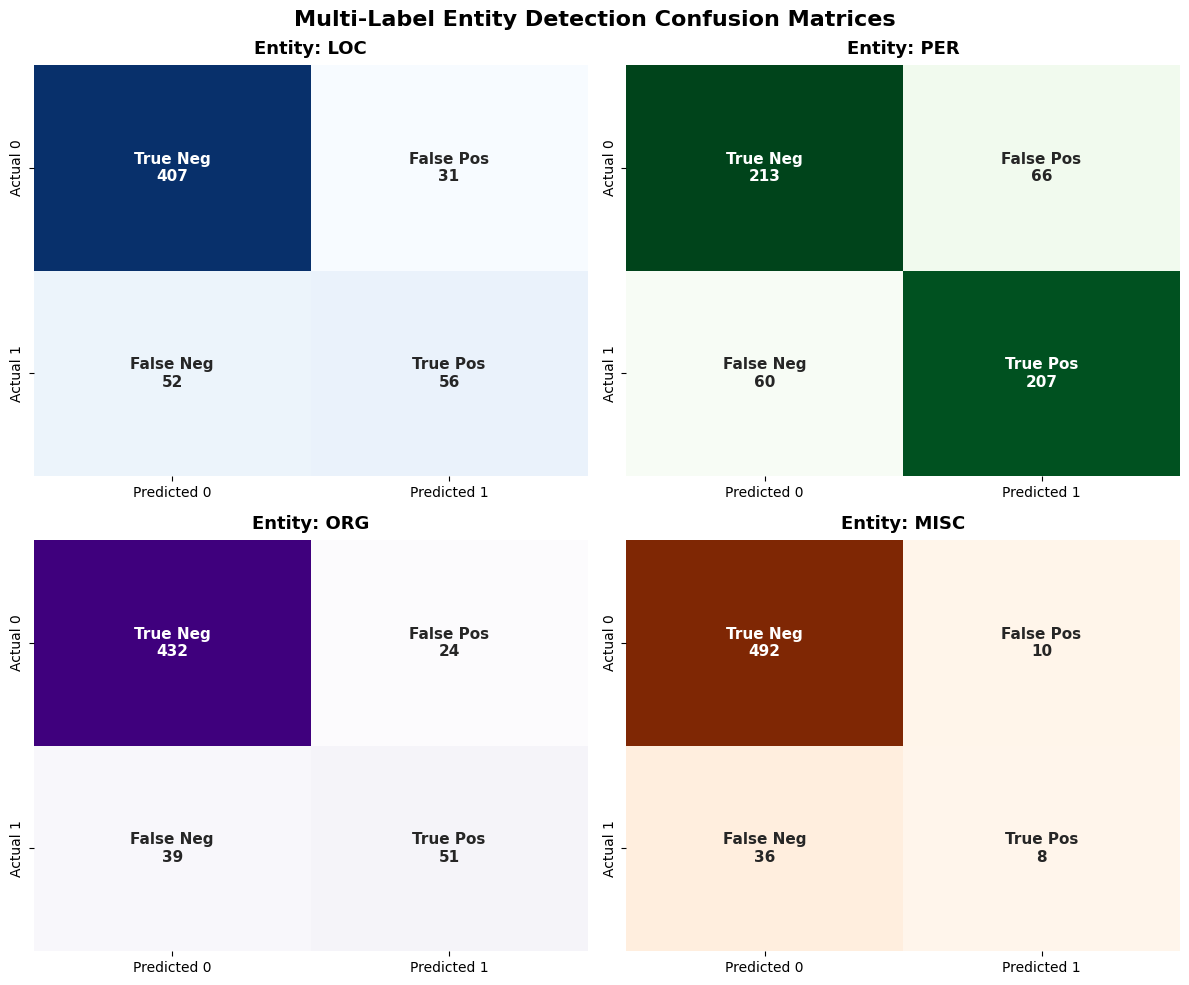

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix

# 1. Compute the multi-label confusion matrices
mcm = multilabel_confusion_matrix(y_test, y_pred)

# 2. Create one single figure containing a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the 2D array of axes to easily loop through them

# Color palettes for each specific entity quadrant
colors = ['Blues', 'Greens', 'Purples', 'Oranges']

# 3. Populate the single diagram grid
for i, (label, matrix) in enumerate(zip(target_labels, mcm)):
    ax = axes[i]
    
    # Define text labels for clarity
    group_names = ['True Neg\n', 'False Pos\n', 'False Neg\n', 'True Pos\n']
    group_counts = [f"{value:d}" for value in matrix.flatten()]
    labels = [f"{v1}{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2, 2)
    
    # Plot onto the current subplot axis
    sns.heatmap(
        matrix, 
        annot=labels, 
        fmt='', 
        cmap=colors[i], 
        cbar=False, 
        ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    
    ax.set_title(f"Entity: {label}", fontsize=13, fontweight='bold', pad=8)

# 4. Final formatting tweaks for the unified plot
plt.suptitle("Multi-Label Entity Detection Confusion Matrices", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import precision_recall_fscore_support

# 1. Generate predictions on your test set
X_test_vec = vectorizer.transform(X_test).toarray()
y_pred = clf.predict(X_test_vec)

# 2. Calculate Micro and Macro metrics
micro_prec, micro_rec, micro_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)
macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

# 3. Print a clean summary table
print("=============================================")
print("        OVERALL MULTI-LABEL METRICS          ")
print("=============================================")
print(f"🔹 MICRO AVERAGE (Global Pool):")
print(f"   • Overall Precision : {micro_prec:.4f}")
print(f"   • Overall Recall    : {micro_rec:.4f}")
print(f"   • Overall F1-Score  : {micro_f1:.4f}")
print("---------------------------------------------")
print(f"🔸 MACRO AVERAGE (Unweighted Per-Class Mean):")
print(f"   • Overall Precision : {macro_prec:.4f}")
print(f"   • Overall Recall    : {macro_rec:.4f}")
print(f"   • Overall F1-Score  : {macro_f1:.4f}")
print("=============================================")

        OVERALL MULTI-LABEL METRICS          
🔹 MICRO AVERAGE (Global Pool):
   • Overall Precision : 0.7108
   • Overall Recall    : 0.6326
   • Overall F1-Score  : 0.6694
---------------------------------------------
🔸 MACRO AVERAGE (Unweighted Per-Class Mean):
   • Overall Precision : 0.6316
   • Overall Recall    : 0.5106
   • Overall F1-Score  : 0.5543


In [14]:
# Cell 1: File Loading and Label Extraction
target_labels = ['LOC', 'PER', 'ORG', 'MISC']

def load_and_parse_file(file_path, has_labels=True):
    ids, texts, labels_list = [], [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip('\n').split('\t')
            if len(parts) >= 2:
                idx = parts[0]
                if has_labels:
                    labels = parts[1]
                    text = parts[2] if len(parts) > 2 else ""
                    labels_list.append(labels)
                else:
                    text = parts[1]
                    labels_list.append("")
                ids.append(idx)
                texts.append(text)
    return ids, texts, labels_list

def extract_binary_flags(label_str):
    flags = {f'has_{l}': 0 for l in target_labels}
    if pd.isna(label_str) or label_str.strip() == "":
        return pd.Series(flags)
    for part in label_str.split(';'):
        for l in target_labels:
            if part.startswith(l + '/'):
                flags[f'has_{l}'] = 1
    return pd.Series(flags)

# Load the files
gt_ids, gt_texts, gt_labels = load_and_parse_file("Explainable AI Tweets Ground Truth.txt", has_labels=True)
ts_ids, ts_texts, _ = load_and_parse_file("Explainable AI Tweets Testset.txt", has_labels=False)

# Build Ground Truth DataFrame and extract y_true
df_gt = pd.DataFrame({'id': gt_ids, 'labels_str': gt_labels, 'text': gt_texts})
df_gt = pd.concat([df_gt, df_gt['labels_str'].apply(extract_binary_flags)], axis=1)
y_true = df_gt[[f'has_{l}' for l in target_labels]].values

# Build Test Set DataFrame
df_ts = pd.DataFrame({'id': ts_ids, 'text': ts_texts})

In [15]:
# Cell 2: Test Set Inference Vectorization
# Vectorize the text from the test set file
X_test_vec = vectorizer.transform(df_ts['text']).toarray()

# Generate multi-label predictions
y_pred = clf.predict(X_test_vec)

In [16]:
# Cell 3: Metrics Evaluation Logs
from sklearn.metrics import classification_report, hamming_loss, precision_recall_fscore_support

micro_prec, micro_rec, micro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)
macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("==================== ALIGNMENT REPORT ====================")
print(f"Total Evaluation Volume : {len(df_gt)} records matched.")
print(f"Dataset Hamming Loss    : {hamming_loss(y_true, y_pred):.4f}\n")
print(f"🔹 MICRO AVERAGE (Global Pool):")
print(f"   Precision: {micro_prec:.4f} | Recall: {micro_rec:.4f} | F1-Score: {micro_f1:.4f}")
print(f"🔸 MACRO AVERAGE (Unweighted Mean):")
print(f"   Precision: {macro_prec:.4f} | Recall: {macro_rec:.4f} | F1-Score: {macro_f1:.4f}\n")
print("---------------- Per-Class Performance ----------------")
print(classification_report(y_true, y_pred, target_names=target_labels, zero_division=0))
print("==========================================================")

==================== ALIGNMENT REPORT ====================
Total Evaluation Volume : 1450 records matched.
Dataset Hamming Loss    : 0.1388

🔹 MICRO AVERAGE (Global Pool):
   Precision: 0.7541 | Recall: 0.5448 | F1-Score: 0.6326
🔸 MACRO AVERAGE (Unweighted Mean):
   Precision: 0.5532 | Recall: 0.3858 | F1-Score: 0.4543

---------------- Per-Class Performance ----------------
              precision    recall  f1-score   support

         LOC       0.43      0.29      0.35        90
         PER       0.85      0.63      0.73       908
         ORG       0.53      0.36      0.43       197
        MISC       0.39      0.26      0.31        77

   micro avg       0.75      0.54      0.63      1272
   macro avg       0.55      0.39      0.45      1272
weighted avg       0.75      0.54      0.63      1272
 samples avg       0.42      0.41      0.41      1272



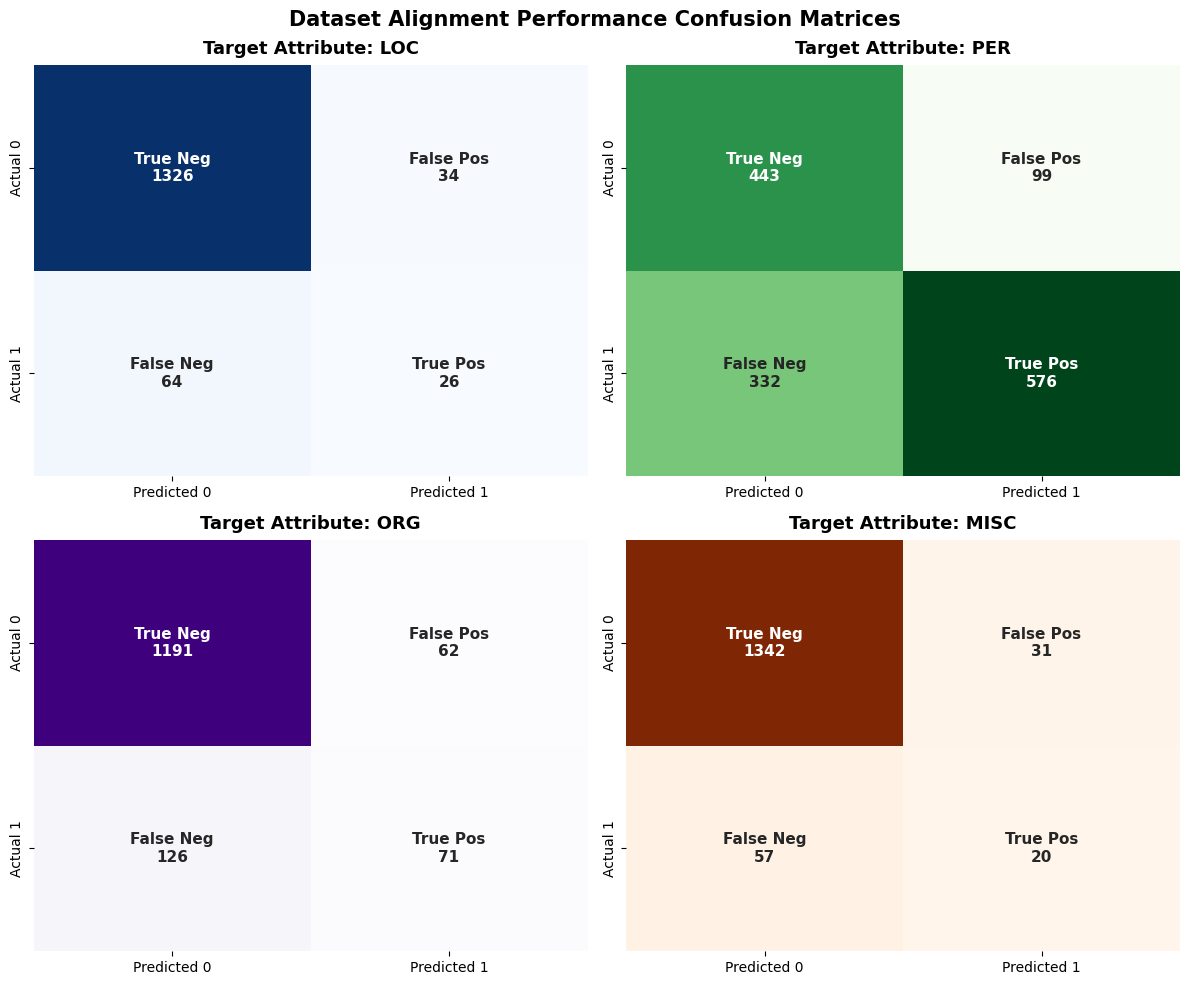

In [17]:
# Cell 4: Unified Confusion Matrix Diagram Grid
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
colors = ['Blues', 'Greens', 'Purples', 'Oranges']

for i, (label, matrix) in enumerate(zip(target_labels, mcm)):
    ax = axes[i]
    group_names = ['True Neg\n', 'False Pos\n', 'False Neg\n', 'True Pos\n']
    group_counts = [f"{value:d}" for value in matrix.flatten()]
    labels = np.asarray([f"{v1}{v2}" for v1, v2 in zip(group_names, group_counts)]).reshape(2, 2)
    
    sns.heatmap(matrix, annot=labels, fmt='', cmap=colors[i], cbar=False, ax=ax,
                annot_kws={"size": 11, "weight": "bold"},
                xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f"Target Attribute: {label}", fontsize=13, fontweight='bold', pad=8)

plt.suptitle("Dataset Alignment Performance Confusion Matrices", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()